# Proyecto 1 – Bank Marketing

**Curso:** Inteligencia Artificial         
**Problema:** Clasificación binaria  
**Modelos:** Regresión Logística y Máquinas de Vectores de Soporte (SVM)  
**Validación:** Validación cruzada estratificada de 10 folds  
**Métricas:** Precision, Recall y F1                  
**Integrantes**: Leonardo Guevara Atehortúa y Ángel Avirama de Oro


## 1. Introducción

Este proyecto desarrolla un modelo de Machine Learning para predecir si un cliente de una institución bancaria portuguesa suscribirá un depósito a plazo después de una campaña de marketing telefónico.

El dataset Bank Marketing fue publicado por el UCI Machine Learning Repository. Contiene 45.211 registros y 17 columnas en la versión "bank-full.csv": 16 variables predictoras y una variable objetivo llamada **y**. UCI clasifica el problema como clasificación y señala que no existen valores faltantes en este dataset.

La variable objetivo es:

- **yes**: el cliente suscribió/contrató el depósito a plazo.
- **no**: el cliente no suscribió/contrató el depósito a plazo.

> **Objetivo:** construir y comparar Regresión Logística y SVM para determinar cuál ofrece el mejor desempeño según Precision, Recall y F1.


## 2. Dominio y contexto del problema

El dominio del problema es banca y marketing directo.

El banco realiza campañas telefónicas para ofrecer un producto financiero denominado "depósito a plazo". En un depósito a plazo, el cliente acepta mantener una cantidad de dinero depositada durante un periodo determinado bajo las condiciones ofrecidas por la entidad financiera.

En este contexto:

- **Cliente:** persona contactada por el banco.
- **Llamada/contacto:** interacción telefónica realizada durante una campaña de marketing.
- **Suscribir:** aceptar o contratar el depósito a plazo ofrecido.
- **Variable objetivo (y):** indica si finalmente el cliente aceptó (yes) o no (no) el producto.

El problema de Machine Learning consistirá en aprender patrones a partir de clientes históricos y utilizar esos patrones para clasificar nuevos casos.
Es decir, predecir si un cliente aceptará contratar un depósito a plazo utilizando sus características personales, financieras y la información disponible de las campañas de marketing.

### Tipo de problema

Es un problema de clasificación binaria (biclase) porque existen únicamente dos resultados posibles:

**no / yes**.


## 3. Fuente y descripción del dataset

**Fuente oficial:** UCI Machine Learning Repository : Bank Marketing.

El dataset está disponible en: https://archive.ics.uci.edu/dataset/222/bank

UCI reporta 45.211 instancias y 17 variables para **bank-full.csv**. La variable **y** es la salida que indica si el cliente suscribió un depósito a plazo.

Se trabajará con:

**bank-full.csv**

El cual contiene contiene:

- 45.211 registros.
- 16 variables predictoras.
- 1 variable objetivo.
- Tanto variables numéricas como categóricas.


La variable **duration** representa la duración de la última llamada en segundos. Es decir, esta variable está disponible después de que la llamada ocurre. Por lo tanto, como el objetivo es predecir antes de realizar la llamada qué clientes tienen mayor probabilidad de aceptar, utilizar **duration** produciría data leakage respecto al escenario de predicción.

Por esta razón, en los modelo predictivos excluiremos la variable **duration**.


In [5]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_validate
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 5. Carga de los datos

El código siguiente carga **bank-full.csv** desde el directorio local.

In [6]:
df = pd.read_csv("bank-full.csv", sep=';')

print(f"Dimensiones del dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas")
display(df.head())


Dimensiones del dataset: 45,211 filas x 17 columnas


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 6. Descripción de las variables

| Variable | Tipo | Descripción |
|---|---|---|
| **age** | Numérica entera | Edad del cliente |
| **job** | Categórica | Tipo de trabajo/ocupación |
| **marital** | Categórica | Estado civil |
| **education** | Categórica | Nivel educativo |
| **default** | Binaria/categórica | Si tiene crédito en mora |
| **balance** | Numérica entera | Saldo promedio anual en euros |
| **housing** | Binaria/categórica | Si tiene préstamo hipotecario |
| **loan** | Binaria/categórica | Si tiene préstamo personal |
| **contact** | Categórica | Tipo de contacto utilizado |
| **day** | Numérica entera | Día del mes del último contacto |
| **month** | Categórica | Mes del último contacto |
| **duration** | Numérica entera | Duración de la última llamada, en segundos |
| **campaign** | Numérica entera | Número de contactos durante la campaña actual |
| **pdays** | Numérica entera | Días desde el contacto anterior; -1 significa que no fue contactado previamente |
| **previous** | Numérica entera | Número de contactos realizados antes de la campaña actual |
| **poutcome** | Categórica | Resultado de la campaña anterior |
| **y** | **Binaria / objetivo** | Si el cliente suscribió el depósito a plazo |

**Nota:** la variable **y** es la variable de salida. Las demás son variables predictoras, aunque **duration** será excluida del modelo final.


In [7]:
df.dtypes.to_frame("dtype")

print("\nInformación general:\n")
df.info()


Información general:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [8]:
# Valores faltantes y duplicados

missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "Valores faltantes": missing,
    "Porcentaje (%)": missing_pct.round(2)
})

print("Valores faltantes:")
display(missing_table)

print(f"Filas duplicadas: {df.duplicated().sum():,}")


Valores faltantes:


,Valores faltantes,Porcentaje (%)
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
default,0,0.0
balance,0,0.0
housing,0,0.0
loan,0,0.0
contact,0,0.0
day,0,0.0


Filas duplicadas: 0


## 7. Análisis exploratorio de datos (EDA)


In [9]:
# Estadísticas descriptivas de las variables numéricas

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

display(df[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


,Cantidad,Porcentaje (%)
y,,
no,39922,88.3
yes,5289,11.7


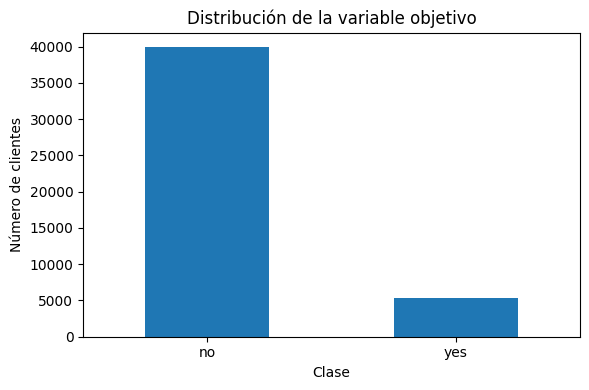

In [10]:
# Distribución de la variable objetivo

target_counts = df["y"].value_counts()
target_pct = df["y"].value_counts(normalize=True).mul(100)

target_table = pd.DataFrame({
    "Cantidad": target_counts,
    "Porcentaje (%)": target_pct.round(2)
})

display(target_table)

plt.figure(figsize=(6, 4))
target_counts.plot(kind="bar")
plt.title("Distribución de la variable objetivo")
plt.xlabel("Clase")
plt.ylabel("Número de clientes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretación de la variable objetivo

La distribución de **y** permite identificar si las clases están balanceadas. En este dataset la clase **no** es mucho más frecuente que **yes**, por lo que existe desbalance de clases.

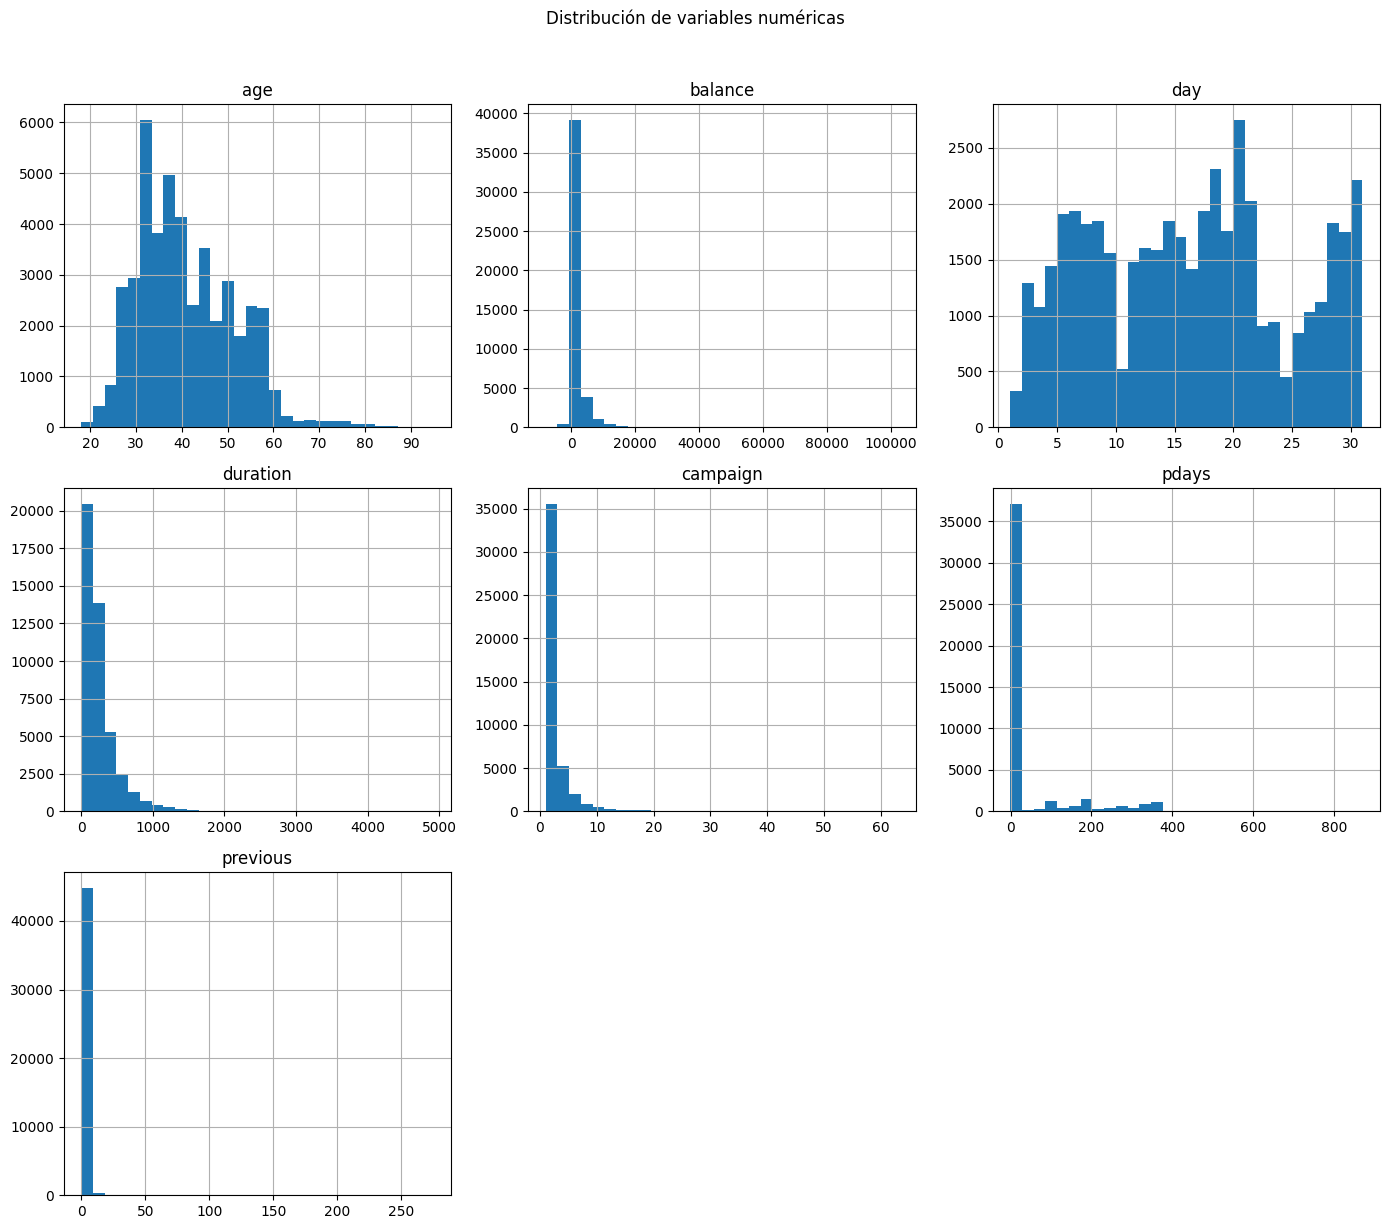

In [11]:
# Histogramas de las variables numéricas

df[numeric_cols].hist(figsize=(14, 12), bins=30)
plt.suptitle("Distribución de variables numéricas", y=1.02)
plt.tight_layout()
plt.show()


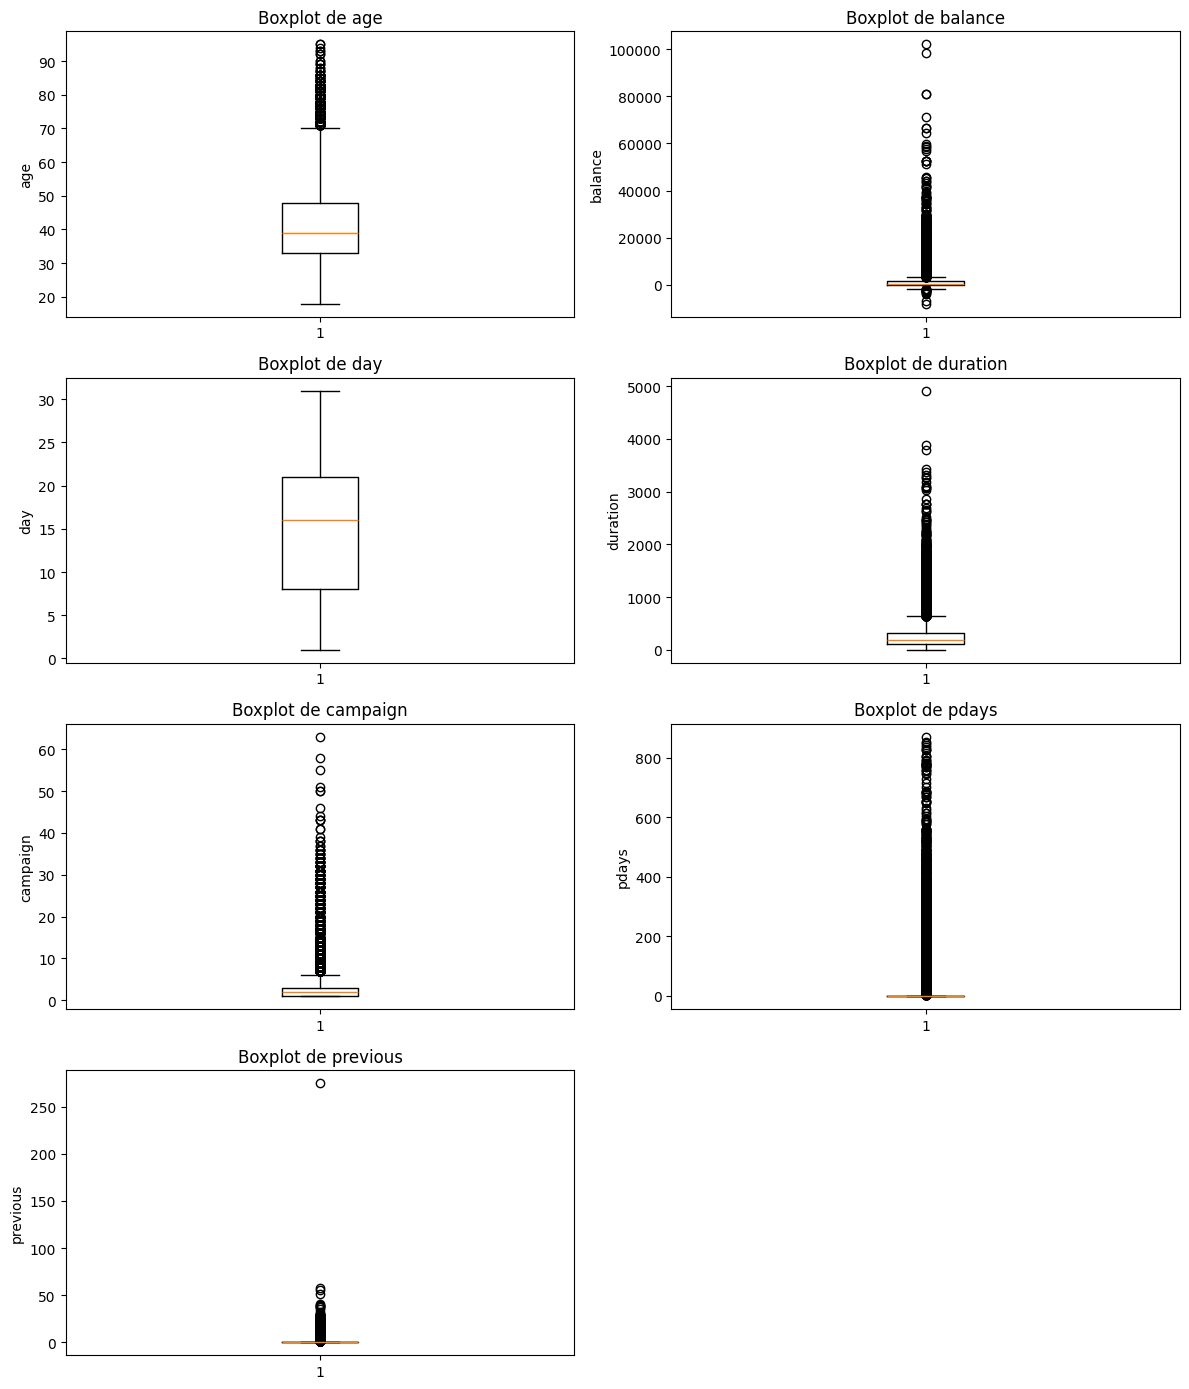

In [12]:
# Boxplots para revisar rangos y posibles valores extremos

fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.ravel()

for ax, col in zip(axes, numeric_cols):
    ax.boxplot(df[col].dropna(), vert=True)
    ax.set_title(f"Boxplot de {col}")
    ax.set_ylabel(col)

for ax in axes[len(numeric_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [13]:
# Frecuencias de variables categóricas

categorical_cols = df.select_dtypes(include="object").columns.tolist()

for col in categorical_cols:
    print(f"\nVariable: {col}")
    display(
        df[col]
        .value_counts(dropna=False)
        .rename("Cantidad")
        .to_frame()
        .assign(Porcentaje=lambda x: (x["Cantidad"] / len(df) * 100).round(2))
    )


Variable: job


,Cantidad,Porcentaje
job,,
blue-collar,9732,21.53
management,9458,20.92
technician,7597,16.80
admin.,5171,11.44
services,4154,9.19
retired,2264,5.01
self-employed,1579,3.49
entrepreneur,1487,3.29
unemployed,1303,2.88



Variable: marital


,Cantidad,Porcentaje
marital,,
married,27214,60.19
single,12790,28.29
divorced,5207,11.52



Variable: education


...

,Cantidad,Porcentaje
month,,
may,13766,30.45
jul,6895,15.25
aug,6247,13.82
jun,5341,11.81
nov,3970,8.78
apr,2932,6.49
feb,2649,5.86
jan,1403,3.10
oct,738,1.63



Variable: poutcome


,Cantidad,Porcentaje
poutcome,,
unknown,36959,81.75
failure,4901,10.84
other,1840,4.07
success,1511,3.34



Variable: y


,Cantidad,Porcentaje
y,,
no,39922,88.3
yes,5289,11.7


In [14]:
# Tasa de suscripción por variables categóricas

def subscription_rate_table(data, column):
    table = pd.crosstab(
        data[column],
        data["y"],
        normalize="index"
    ).mul(100)
    return table.rename(columns={"no": "% no", "yes": "% yes"}).round(2)

selected_cat = ["job", "marital", "education", "housing", "loan", "contact", "poutcome", "month", "default"]

for col in selected_cat:
    print(f"\nTasa de suscripción según {col}:")
    display(subscription_rate_table(df, col))



Tasa de suscripción según job:


y,% no,% yes
job,,
admin.,87.80,12.20
blue-collar,92.73,7.27
entrepreneur,91.73,8.27
housemaid,91.21,8.79
management,86.24,13.76
retired,77.21,22.79
self-employed,88.16,11.84
services,91.12,8.88
student,71.32,28.68



Tasa de suscripción según marital:


y,% no,% yes
marital,,
divorced,88.05,11.95
married,89.88,10.12
single,85.05,14.95



Tasa de suscripción según education:


...

y,% no,% yes
poutcome,,
failure,87.39,12.61
other,83.32,16.68
success,35.27,64.73
unknown,90.84,9.16



Tasa de suscripción según month:


y,% no,% yes
month,,
apr,80.32,19.68
aug,88.99,11.01
dec,53.27,46.73
feb,83.35,16.65
jan,89.88,10.12
jul,90.91,9.09
jun,89.78,10.22
mar,48.01,51.99
may,93.28,6.72



Tasa de suscripción según default:


y,% no,% yes
default,,
no,88.20,11.80
yes,93.62,6.38


In [15]:
# Tasas de suscripción para variables numéricas discretas

for col in ["campaign", "previous"]:
    temp = (
        df.groupby(col)["y"]
        .apply(lambda s: (s == "yes").mean() * 100)
        .reset_index(name="Tasa_yes_%")
    )

    print(f"\nTasa de suscripción según {col}:")
    display(temp.head(20))



Tasa de suscripción según campaign:


,campaign,Tasa_yes_%
0,1,14.597583
1,2,11.203519
2,3,11.193624
3,4,9.000568
4,5,7.879819
5,6,7.126259
6,7,6.394558
7,8,5.925926
8,9,6.422018
9,10,5.263158



Tasa de suscripción según previous:


,previous,Tasa_yes_%
0,0,9.157331
1,1,21.031746
2,2,21.652422
3,3,25.744308
4,4,23.949580
5,5,26.361656
6,6,29.963899
7,7,26.341463
8,8,30.232558
9,9,26.086957


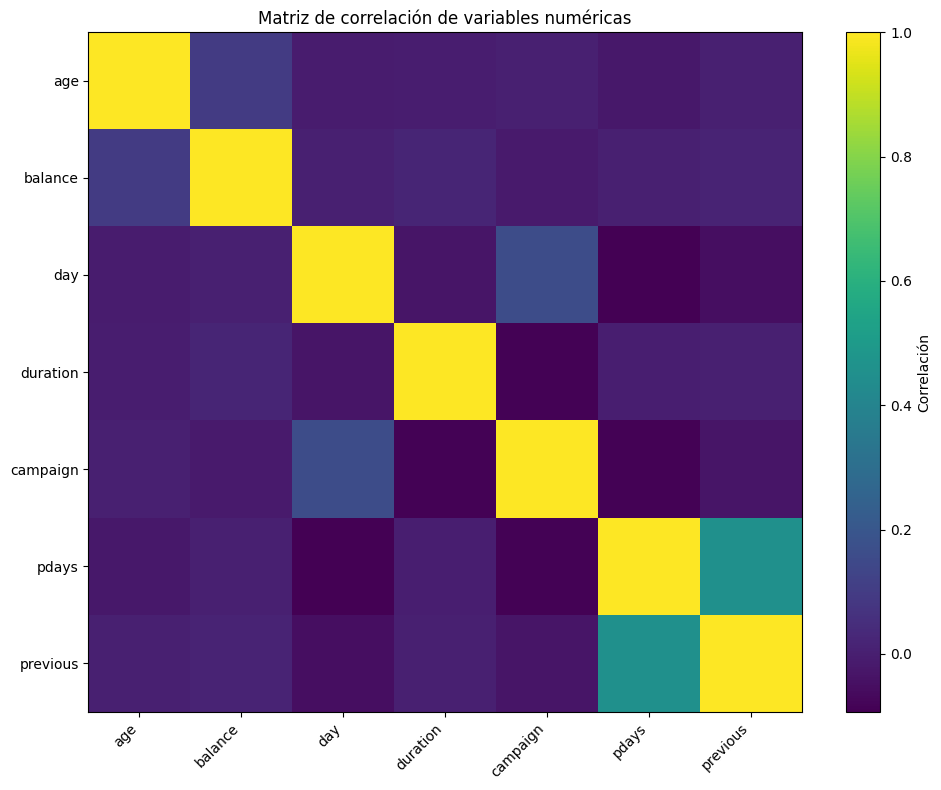

,age,balance,day,duration,campaign,pdays,previous
age,1.00,0.10,-0.01,-0.00,0.00,-0.02,0.00
balance,0.10,1.00,0.00,0.02,-0.01,0.00,0.02
day,-0.01,0.00,1.00,-0.03,0.16,-0.09,-0.05
duration,-0.00,0.02,-0.03,1.00,-0.08,-0.00,0.00
campaign,0.00,-0.01,0.16,-0.08,1.00,-0.09,-0.03
pdays,-0.02,0.00,-0.09,-0.00,-0.09,1.00,0.45
previous,0.00,0.02,-0.05,0.00,-0.03,0.45,1.00


In [16]:
# Correlación entre variables numéricas

corr = df[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr, interpolation="nearest", aspect="auto")
plt.colorbar(label="Correlación")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.show()

display(corr.round(2))


## 8. Conclusiones del EDA

- El dataset combina variables numéricas y categóricas, por lo que será necesario realizar preprocesamiento.
- La variable objetivo presenta desbalance entre **no** y **yes**.
- Las variables **age**, **balance**, **duration**, **campaign**, **pdays** y **previous** tienen escalas diferentes, por lo que las variables numéricas deberán escalarse antes de entrenar.
- Las variables categóricas requieren codificación para poder ser utilizadas por los algoritmos.
- **duration** será excluida del conjunto final de predictores porque se conoce después de la llamada y puede introducir información que no estaría disponible en un escenario de predicción previo al contacto.
- La variable **pdays** suelen tener el valor **-1**,  esto significa que el cliente no fue contactado previamente.


# 9. Preparación para Machine Learning

### Variable objetivo:

Se transforma:

- **no** : 0
- **yes** : 1

### Variables predictoras:

Se elimina la variable objetivo, y la variable **duration** para evitar data leaking.

### Preprocesamiento:

- Variables numéricas: imputación de la mediana y StandardScaler.
- Variables categóricas: imputación de la moda y OneHotEncoder.

Todo el preprocesamiento dentro de un Pipeline y un ColumnTransformer.


In [17]:
# Preparar X e y

df_model = df.copy()

df_model["y"] = df_model["y"].map({"no": 0, "yes": 1})

X = df_model.drop(columns=["y", "duration"])
y = df_model["y"]

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include="object").columns.tolist()

print("Variables numéricas:")
print(numeric_features)

print("\nVariables categóricas:")
print(categorical_features)

print(f"\nNúmero de predictores utilizados: {X.shape[1]}")


Variables numéricas:
['age', 'balance', 'day', 'campaign', 'pdays', 'previous']

Variables categóricas:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Número de predictores utilizados: 15


In [18]:
# División entrenamiento/prueba

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Entrenamiento: {X_train.shape[0]:,} registros")
print(f"Prueba:        {X_test.shape[0]:,} registros")

print("\nDistribución de clases en entrenamiento:")
display(y_train.value_counts(normalize=True).rename("proporción").to_frame())

print("\nDistribución de clases en prueba:")
display(y_test.value_counts(normalize=True).rename("proporción").to_frame())

Entrenamiento: 36,168 registros
Prueba:        9,043 registros

Distribución de clases en entrenamiento:


,proporción
y,
0,0.883018
1,0.116982



Distribución de clases en prueba:


,proporción
y,
0,0.883003
1,0.116997


In [19]:
# Pipelines de preprocesamiento

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=RANDOM_STATE
)

# 10. Regresión Logística

El hiperparámetro **C** controla la fuerza de la regularización:

- Valores pequeños de **C** : regularización más fuerte.
- Valores grandes de **C** : regularización más débil.

Se utilizará **GridSearchCV** con **10 folds estratificados** para encontrar la combinación que maximiza F1 en validación.


In [20]:
# Pipeline de Regresión Logística

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ]
)

logistic_param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__solver": ["liblinear", "lbfgs"]
}

logistic_grid = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=False
)

In [21]:
# Entrenamiento y búsqueda de hiperparámetros

logistic_grid.fit(X_train, y_train) #Entrenando Regresión Logística con validación cruzada de 10 folds

print(logistic_grid.best_params_) #Print de mejores hiperparametros

print(f"\nMejor F1 promedio de validación cruzada: {logistic_grid.best_score_:.4f}")


{'model__C': 100, 'model__solver': 'lbfgs'}

Mejor F1 promedio de validación cruzada: 0.3734


In [22]:
# Evaluación de Regresión Logística sobre el conjunto de prueba

best_logistic = logistic_grid.best_estimator_
y_pred_lr = best_logistic.predict(X_test)

precision_lr = precision_score(y_test, y_pred_lr, zero_division=0)
recall_lr = recall_score(y_test, y_pred_lr, zero_division=0)
f1_lr = f1_score(y_test, y_pred_lr, zero_division=0)

print("Resultados - Regresión Logística")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall:    {recall_lr:.4f}")
print(f"F1:        {f1_lr:.4f}")

print("\nReporte de clasificación:")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["No", "Yes"],
    digits=4,
    zero_division=0
))


Resultados - Regresión Logística
Precision: 0.2667
Recall:    0.6238
F1:        0.3736

Reporte de clasificación:
              precision    recall  f1-score   support

          No     0.9394    0.7727    0.8479      7985
         Yes     0.2667    0.6238    0.3736      1058

    accuracy                         0.7553      9043
   macro avg     0.6030    0.6983    0.6108      9043
weighted avg     0.8607    0.7553    0.7924      9043



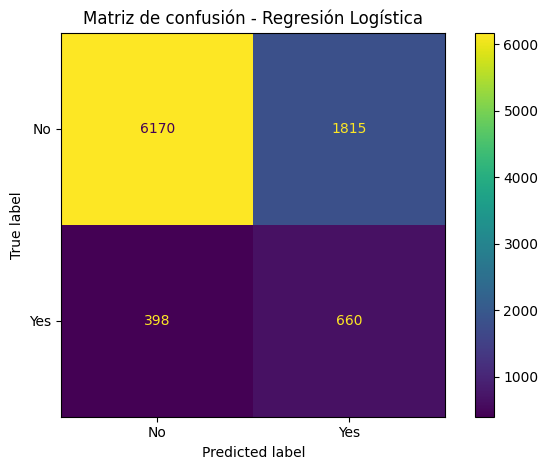

In [23]:
# Matriz de confusión - Regresión Logística

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=["No", "Yes"]
)
plt.title("Matriz de confusión - Regresión Logística")
plt.tight_layout()
plt.show()